In [111]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_ind, f_oneway, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error

In [108]:
# Graph settings
sns.set_theme(style="whitegrid", font="DejaVu Sans", rc={"figure.dpi": 120})

In [112]:
# Loading Dataset
df = pd.read_excel('/content/Flight_dataset[4039].xlsx')

In [113]:
# Insights
print('HEAD:\n',df.head())
print('='*75)
print('INFO:')
print(df.info())
print('='*75)
print('DESCRIBE:\n',df.describe)
print('='*75)
print('SHAPE:',df.shape)
print('='*75)
print('MISSING VALUES:\n',df.isnull().sum())
print('='*75)
Total_Null_Count = df.isnull().sum().sum()
print('TOTAL NULL COUNT:', Total_Null_Count)
print('='*75)
print("BASIC NUMERICAL STATISTICS:")
print(df[['price', 'duration', 'days_left']].describe().round(2))
print('='*75)

HEAD:
    Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left   price  
0          Night           Mumbai  Economy      2.17        1.0  5953.0  
1        Morning           Mumbai  Economy      2.33        1.0  5953.0  
2  Early_Morning           Mumbai  Economy       NaN        1.0  5956.0  
3      Afternoon           Mumbai  Economy      2.25        1.0  5955.0  
4        Morning           Mumbai  Economy      2.33        1.0  5955.0  
INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column      

In [114]:
# Preprocessing
df = df.drop(columns=['Unnamed: 0','flight']) # Unnecessary Columns - not affected by target variable
df = df.dropna() # Dropping Null Values

print(df.info())
print('='*75)
print('CLEANED SHAPE:',df.shape)
print('='*75)
print("BASIC NUMERICAL STATISTICS:")
print(df[['price', 'duration', 'days_left']].describe().round(2))
print('='*75)

<class 'pandas.core.frame.DataFrame'>
Index: 300133 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300133 non-null  object 
 1   source_city       300133 non-null  object 
 2   departure_time    300133 non-null  object 
 3   stops             300133 non-null  object 
 4   arrival_time      300133 non-null  object 
 5   destination_city  300133 non-null  object 
 6   class             300133 non-null  object 
 7   duration          300133 non-null  float64
 8   days_left         300133 non-null  float64
 9   price             300133 non-null  float64
dtypes: float64(3), object(7)
memory usage: 25.2+ MB
None
CLEANED SHAPE: (300133, 10)
BASIC NUMERICAL STATISTICS:
           price   duration  days_left
count  300133.00  300133.00  300133.00
mean    20890.24      12.22      26.01
std     22698.36       7.19      13.56
min      1105.00       0.83       1.00
25%      

Skewness: 1.0613


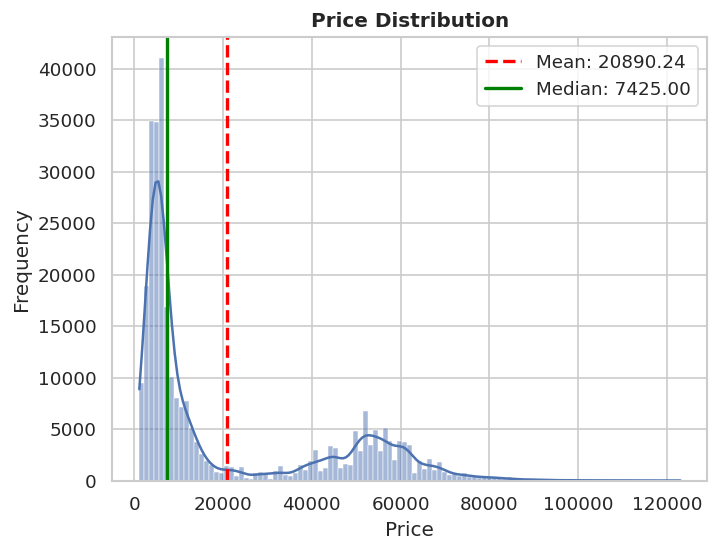

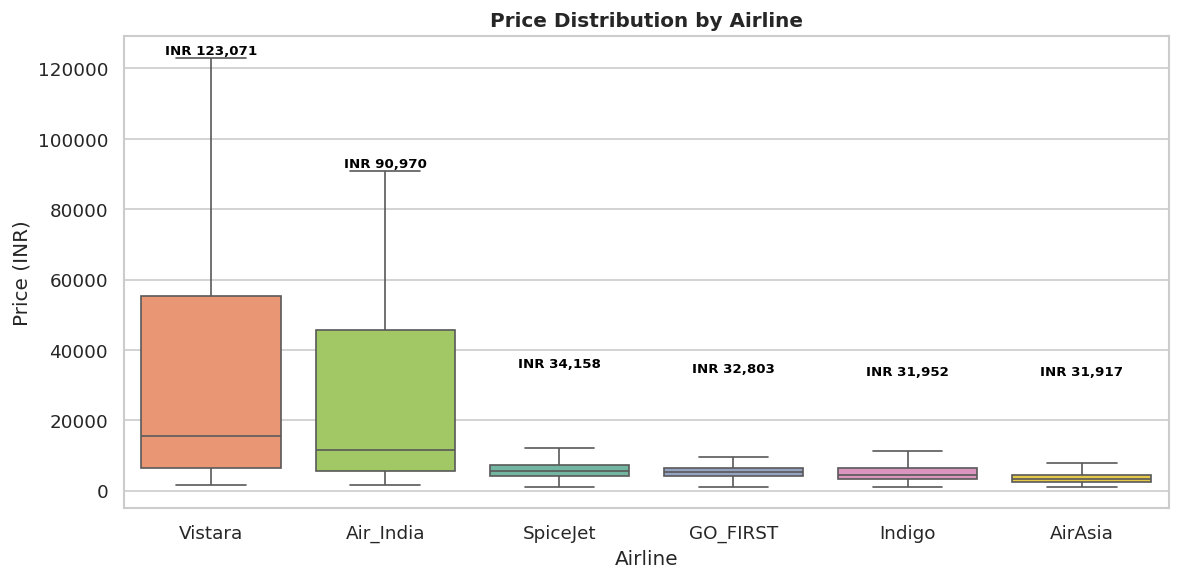


Mean price by airline:
airline
AirAsia       4090.956886
Indigo        5323.866665
GO_FIRST      5651.220673
SpiceJet      6179.303996
Air_India    23507.930271
Vistara      30397.094826
Name: price, dtype: float64


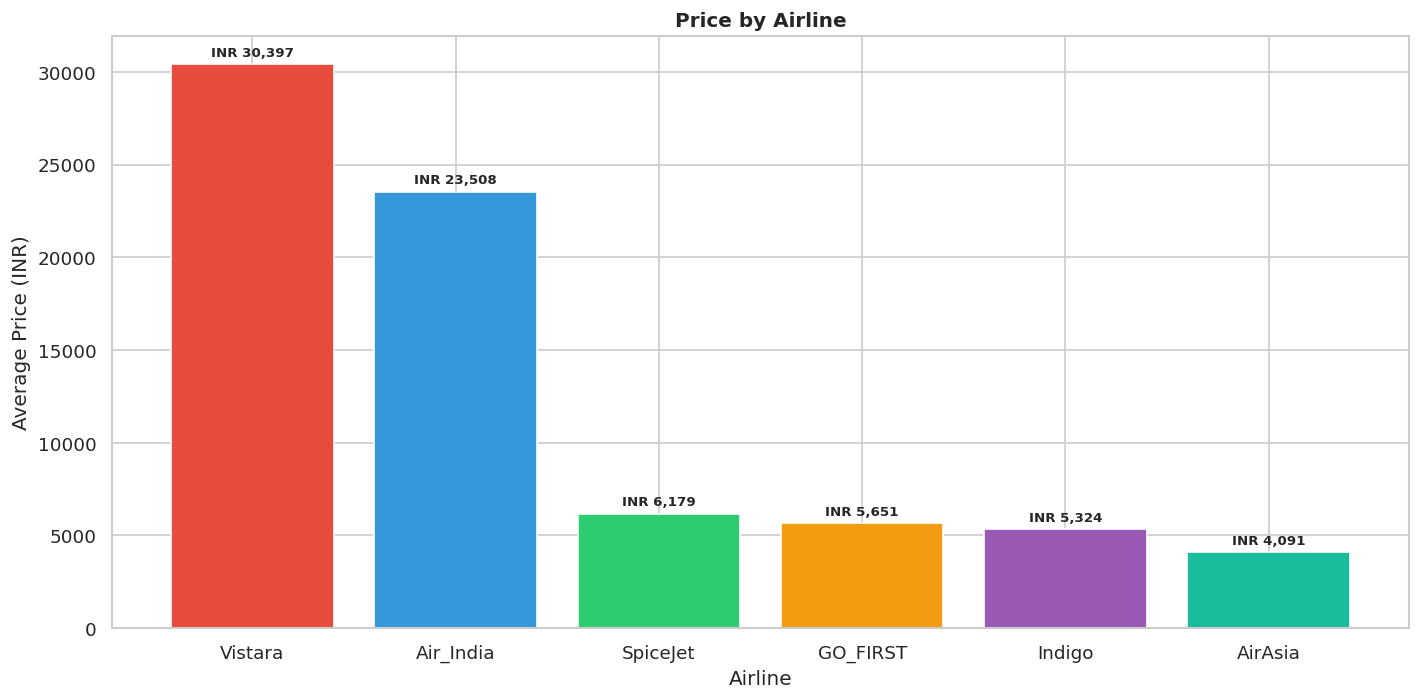


Mean price by class:
class
Business    52540.081124
Economy      6571.804105
Name: price, dtype: float64


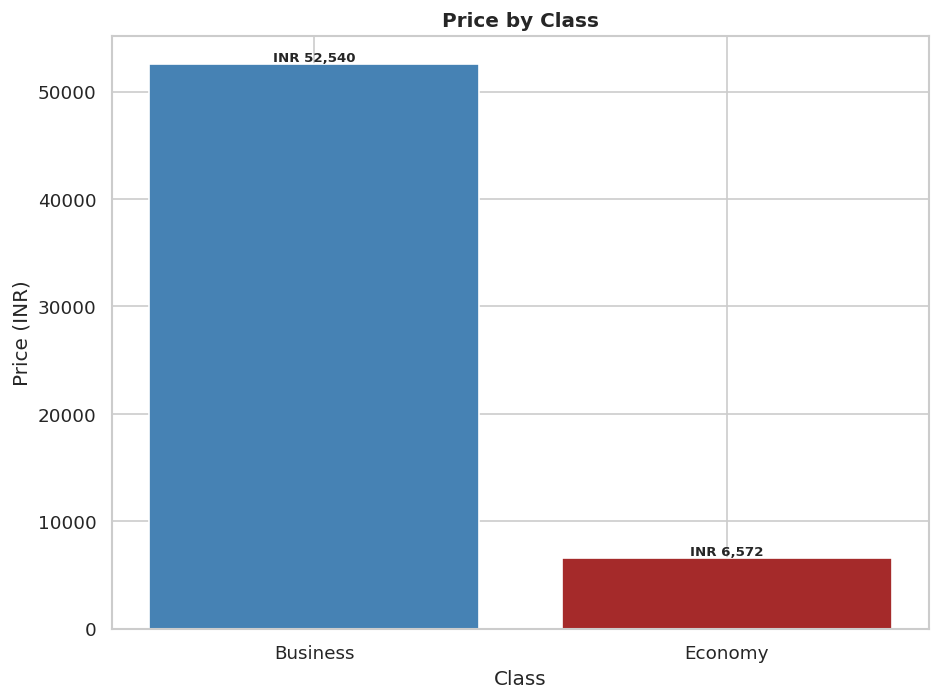


Mean price by stops:
stops
one            22901.513566
two_or_more    14113.450775
zero            9376.410817
Name: price, dtype: float64


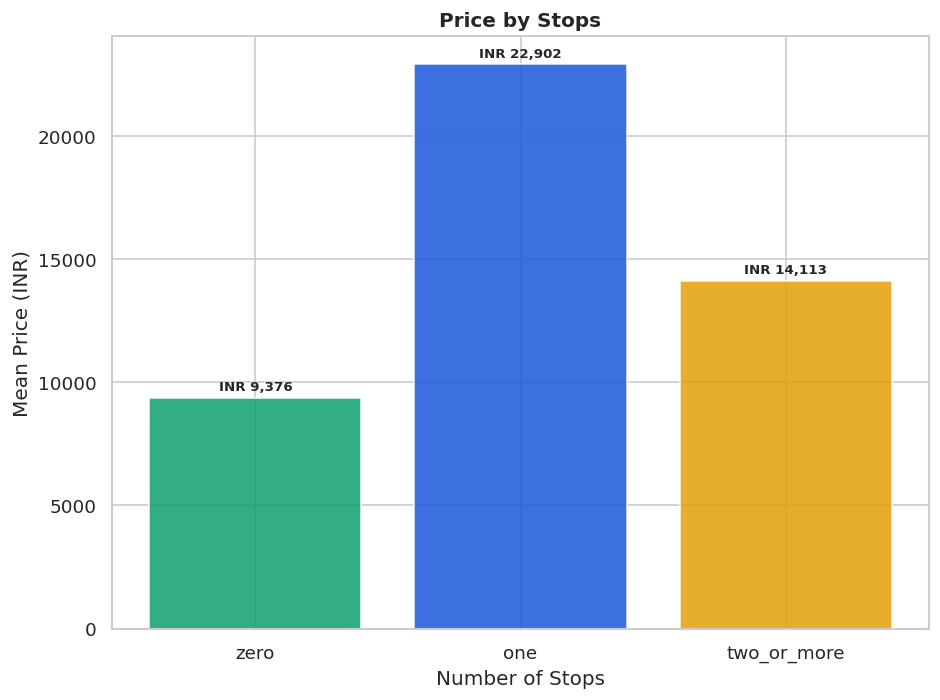


Mean price by departure_time:
departure_time
Night            23062.350564
Morning          21631.475281
Evening          21233.207094
Early_Morning    20371.118782
Afternoon        18179.725110
Late_Night        9295.299387
Name: price, dtype: float64


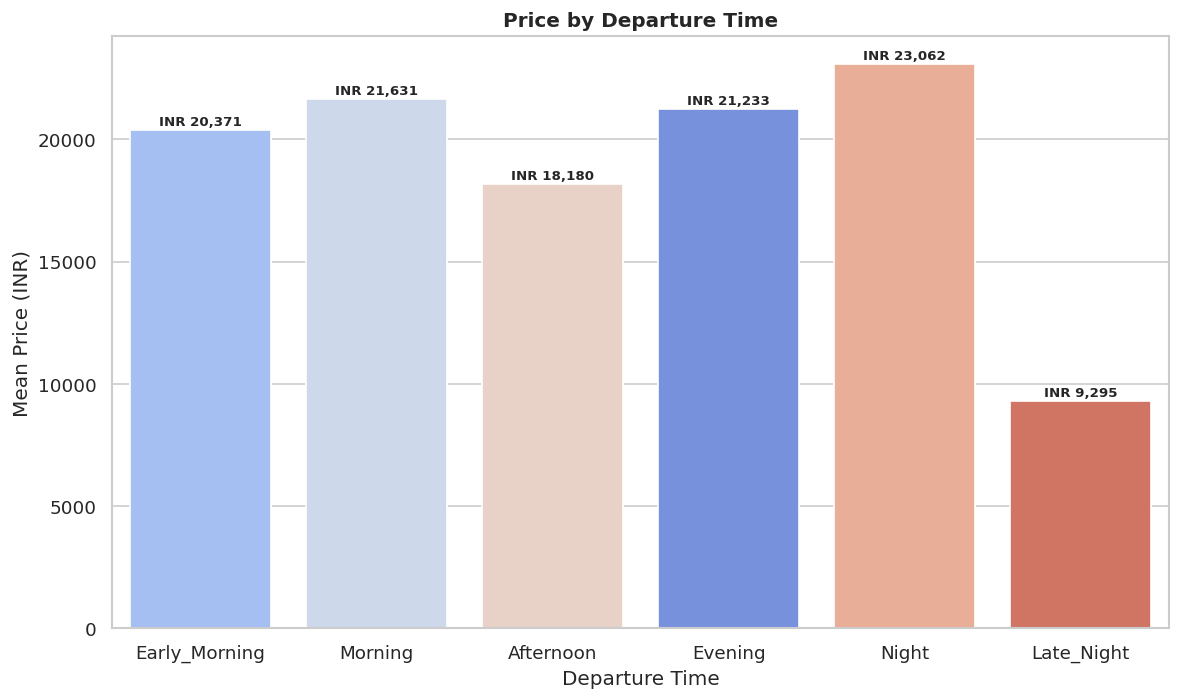

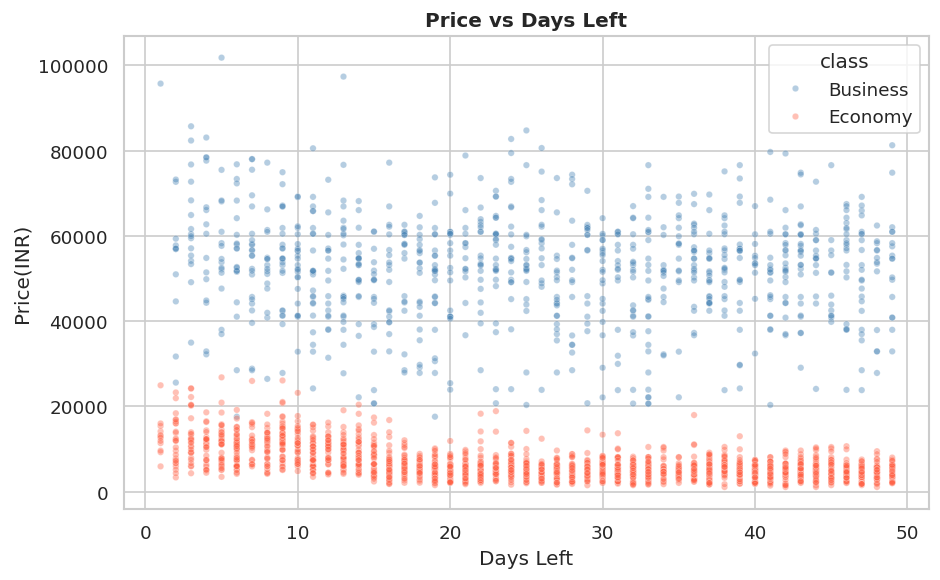

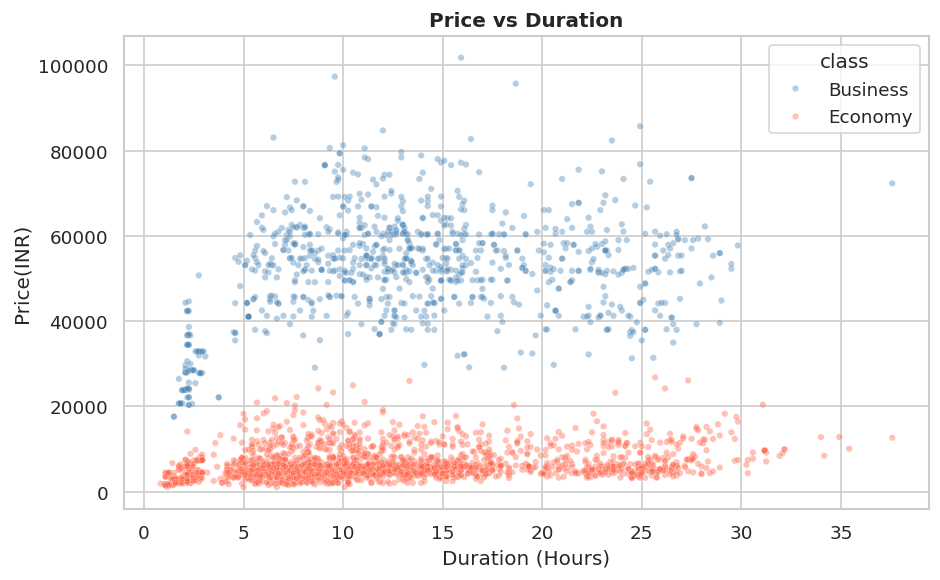

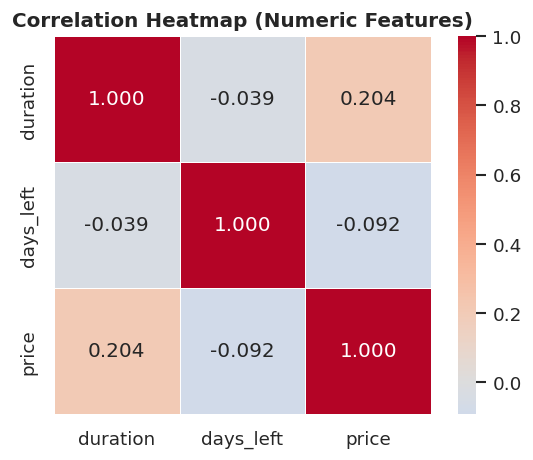

In [115]:
# EDA

# Price Distribution Skewness
print(f"Skewness: {df['price'].skew():.4f}")
# Price distribution
mean_price = df['price'].mean()
median_price = df['price'].median()

sns.histplot(df['price'], kde=True)
plt.axvline(mean_price, color='red', linestyle='--', linewidth=2,
            label=f"Mean: {mean_price:.2f}")
plt.axvline(median_price, color='green', linestyle='-', linewidth=2,
            label=f"Median: {median_price:.2f}")
plt.title("Price Distribution", fontweight= 'bold')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('Price Distribution.png')
plt.show()
print('\n')

# Price Distribution by Airline
airline_order = df.groupby('airline')['price'].median().sort_values(ascending=False).index
max_vals = df.groupby('airline')['price'].max()

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x='airline', y='price', order=airline_order, palette='Set2',
            hue='airline', ax=ax, showfliers=False)

for i, airline in enumerate(airline_order):
    max_val = max_vals[airline]
    ax.text(i, max_val, f"INR {max_val:,.0f}", ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='black')
ax.set_title('Price Distribution by Airline', fontweight='bold')
ax.set_xlabel('Airline')
ax.set_ylabel('Price (INR)')
plt.tight_layout()
plt.savefig('Price Distribution by Airline.png')
plt.show()

# Price by Airline
print("\nMean price by airline:")
print(df.groupby('airline')['price'].mean().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 6))
avg_airline = df.groupby('airline')['price'].mean().sort_values(ascending=False)
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
bars = ax.bar(avg_airline.index, avg_airline.values, color=colors, edgecolor='white')
ax.set_title('Price by Airline', fontweight='bold')
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Average Price (INR)', fontsize=12)
for bar, val in zip(bars, avg_airline.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'INR {val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('Price by Airline.png')
plt.show()

# Price by Class
print("\nMean price by class:")
print(df.groupby('class')['price'].mean())

fig, ax = plt.subplots(figsize=(8, 6))
class_avg = df.groupby('class')['price'].mean()
bars =(ax.bar(class_avg.index, class_avg.values, color=['steelblue', 'brown']))
ax.set_title('Price by Class', fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Price (INR)')
ax.bar_label(bars, fmt= 'INR {:,.0f}', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('Price by Class.png')
plt.show()

# Price by Stops
print("\nMean price by stops:")
print(df.groupby('stops')['price'].mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
sp = (df.groupby('stops')['price']
      .mean().reindex(['zero', 'one', 'two_or_more']))
ax.bar(sp.index, sp.values,
            color=['#0e9f6e', '#1a56db', '#e3a008'], alpha=0.85)
ax.set_title('Price by Stops', fontweight='bold')
ax.set_xlabel('Number of Stops')
ax.set_ylabel('Mean Price (INR)')
for i, (idx, val) in enumerate(sp.items()):
  ax.text(i, val + 300, f'INR {val:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('Price by Stops.png')
plt.show()

# Price by Departure Time
print("\nMean price by departure_time:")
print(df.groupby('departure_time')['price'].mean().sort_values(ascending=False))

time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']
dt= df.groupby('departure_time')['price'].mean().reindex(time_order)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='departure_time', y='price', order=time_order,
            estimator=np.mean, palette='coolwarm', hue='departure_time', errorbar=None, ax=ax)
ax.set_title('Price by Departure Time', fontweight='bold')
ax.set_xlabel('Departure Time')
ax.set_ylabel('Mean Price (INR)')
for i, val in enumerate(dt.values):
  ax.text(i, val + 200, f'INR {val:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('Price by Departure Time.png')
plt.show()
print('\n')
# Price by Days Left
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=sample, x='days_left', y='price', hue='class',
                palette=['steelblue', 'tomato'], alpha=0.4, s=15, ax=ax)
ax.set_title('Price vs Days Left', fontweight='bold')
ax.set_xlabel('Days Left')
ax.set_ylabel('Price(INR)')
plt.tight_layout()
plt.savefig('Price by Days Left.png')
plt.show()
print('\n')

# Price by Duration
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x='duration', y='price', hue='class',
                palette=['steelblue', 'tomato'], alpha=0.4, s=15, ax=ax)
ax.set_title('Price vs Duration', fontweight='bold')
ax.set_xlabel('Duration (Hours)')
ax.set_ylabel('Price(INR)')
plt.tight_layout()
plt.savefig('Price by Duration.png')
plt.show()

# Correlation Heatmap
num_cols = ['duration', 'days_left', 'price']
corr_mat = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.savefig('Correlation Heatmap .png')
plt.show()

In [116]:
# Hypothesis Testing, ANOVA & Pearson Correlation Coefficient

# T-TEST: CLASS vs PRICE
economy = df[df['class'] == 'Economy']['price']
business = df[df['class'] == 'Business']['price']
t_stat, p_value = ttest_ind(economy, business)

print("T-Test: Class vs Price")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → Significant effect")
else:
    print("Result: Fail to reject H0 → No significant effect")

# ANOVA: CLASS vs PRICE
class_groups = [group['price'].values for name, group in df.groupby('class')]
f_stat, p_value = f_oneway(*class_groups)

print("\nANOVA: Class vs Price")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → Significant difference")
else:
    print("Result: Fail to reject H0 → No significant difference")

# ANOVA: AIRLINE vs PRICE
airline_groups = [group['price'].values for name, group in df.groupby('airline')]
f_stat, p_value = f_oneway(*airline_groups)

print("\nANOVA: Airline vs Price")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → Significant difference")
else:
    print("Result: Fail to reject H0 → No significant difference")

# ANOVA: STOPS vs PRICE
stops_groups = [group['price'].values for name, group in df.groupby('stops')]
f_stat, p_value = f_oneway(*stops_groups)

print("\nANOVA: Stops vs Price")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → Significant effect")
else:
    print("Result: Fail to reject H0 → No significant effect")

# # ANOVA: SOURCE CITY vs PRICE
# source_city_groups = [group['price'].values for name, group in df.groupby('source_city')]
# f_stat, p_value = f_oneway(*source_city_groups)

# print("\nANOVA: Source City vs Price")
# print("F-statistic:", f_stat)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print("Result: Reject H0 → Significant difference")
# else:
#     print("Result: Fail to reject H0 → No significant difference")

# # ANOVA: DEPARTURE TIME vs PRICE
# departure_time_groups = [group['price'].values for name, group in df.groupby('departure_time')]
# f_stat, p_value = f_oneway(*departure_time_groups)

# print("\nANOVA: Departure Time vs Price")
# print("F-statistic:", f_stat)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print("Result: Reject H0 → Significant difference")
# else:
#     print("Result: Fail to reject H0 → No significant difference")

# # ANOVA: DESTINATION CITY vs PRICE
# destination_city_groups = [group['price'].values for name, group in df.groupby('destination_city')]
# f_stat, p_value = f_oneway(*destination_city_groups)

# print("\nANOVA: Destination City vs Price")
# print("F-statistic:", f_stat)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print("Result: Reject H0 → Significant difference")
# else:
#     print("Result: Fail to reject H0 → No significant difference")

# # ANOVA: ARRIVAL TIME vs PRICE
# arrival_time_groups = [group['price'].values for name, group in df.groupby('arrival_time')]
# f_stat, p_value = f_oneway(*arrival_time_groups)

# print("\nANOVA: Arrival Time vs Price")
# print("F-statistic:", f_stat)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print("Result: Reject H0 → Significant difference")
# else:
#     print("Result: Fail to reject H0 → No significant difference")

# DAYS LEFT CORRELATION TEST
corr, p_value = pearsonr(df['days_left'], df['price'])

print("\nCorrelation Test: Days Left vs Price")
print("Correlation coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant relationship")
else:
    print("Result: No significant relationship")

# DURATION CORRELATION TEST
corr, p_value = pearsonr(df['duration'], df['price'])

print("\nCorrelation Test: Duration vs Price")
print("Correlation coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant relationship")
else:
    print("Result: No significant relationship")

T-Test: Class vs Price
T-statistic: -1480.6808115131385
P-value: 0.0
Result: Reject H0 → Significant effect

ANOVA: Class vs Price
F-statistic: 2192415.6655833093
P-value: 0.0
Result: Reject H0 → Significant difference

ANOVA: Airline vs Price
F-statistic: 17193.884085598915
P-value: 0.0
Result: Reject H0 → Significant difference

ANOVA: Stops vs Price
F-statistic: 6476.172855253605
P-value: 0.0
Result: Reject H0 → Significant effect

Correlation Test: Days Left vs Price
Correlation coefficient: -0.09200550403266719
P-value: 0.0
Result: Significant relationship

Correlation Test: Duration vs Price
Correlation coefficient: 0.2042188721807346
P-value: 0.0
Result: Significant relationship


In [118]:
# Encoding and Feature Selection
df_model = df.copy()

le = LabelEncoder()
categorical_cols = ['airline', 'source_city', 'destination_city',
                    'departure_time', 'arrival_time']

for col in categorical_cols:
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df_model['stops_num'] = df_model['stops'].map(stops_map)

df_model['class_binary'] = (df_model['class'] == 'Business').astype(int)

feature_cols = ['airline_encoded', 'source_city_encoded', 'destination_city_encoded',
    'departure_time_encoded', 'arrival_time_encoded', 'stops_num', 'class_binary',
    'duration', 'days_left']

print(f"  Features: {feature_cols}")
print(f"  Target: ['price']")

X = df_model[feature_cols]
y = df_model['price']

  Features: ['airline_encoded', 'source_city_encoded', 'destination_city_encoded', 'departure_time_encoded', 'arrival_time_encoded', 'stops_num', 'class_binary', 'duration', 'days_left']
  Target: ['price']


In [122]:
# Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data: {X_train.shape[0]:,} rows")
print(f"Testing data: {X_test.shape[0]:,} rows")

# Models
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Gradiant Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate = 0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

Training data: 240,106 rows
Testing data: 60,027 rows


In [123]:
# Evaluation
def evaluate(y_test, y_pred):
  y_pred_safe = np.maximum(y_pred, 0)

  R2 = r2_score(y_test, y_pred)
  RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
  MAPE = mean_absolute_percentage_error(y_test, y_pred)
  RMLSE = np.sqrt(mean_squared_log_error(y_test, y_pred_safe))
  return R2, RMSE, MAPE, RMLSE

lr_results = evaluate(y_test, y_pred_lr)
rf_results = evaluate(y_test, y_pred_rf)
gb_results = evaluate(y_test, y_pred_gb)

print(f"Linear Regression | R2: {lr_results[0]*100:.2f}% | RMSE: {lr_results[1]:.4f} | MAPE: {lr_results[2]*100:.2f}% | RMSLE: {lr_results[3]:.4f}")
print(f"Random Forrest | R2: {rf_results[0]*100:.2f}% | RMSE: {rf_results[1]:.4f} | MAPE: {rf_results[2]*100:.2f}% | RMSLE: {rf_results[3]:.4f}")
print(f"Gradient Boosting | R2: {gb_results[0]*100:.2f}% | RMSE: {gb_results[1]:.4f} | MAPE: {gb_results[2]*100:.2f}% | RMSLE: {gb_results[3]:.4f}")

Linear Regression | R2: 90.60% | RMSE: 6959.3027 | MAPE: 42.00% | RMSLE: 1.7176
Random Forrest | R2: 97.98% | RMSE: 3226.2902 | MAPE: 11.61% | RMSLE: 0.1752
Gradient Boosting | R2: 96.66% | RMSE: 4151.9800 | MAPE: 17.13% | RMSLE: 0.2259


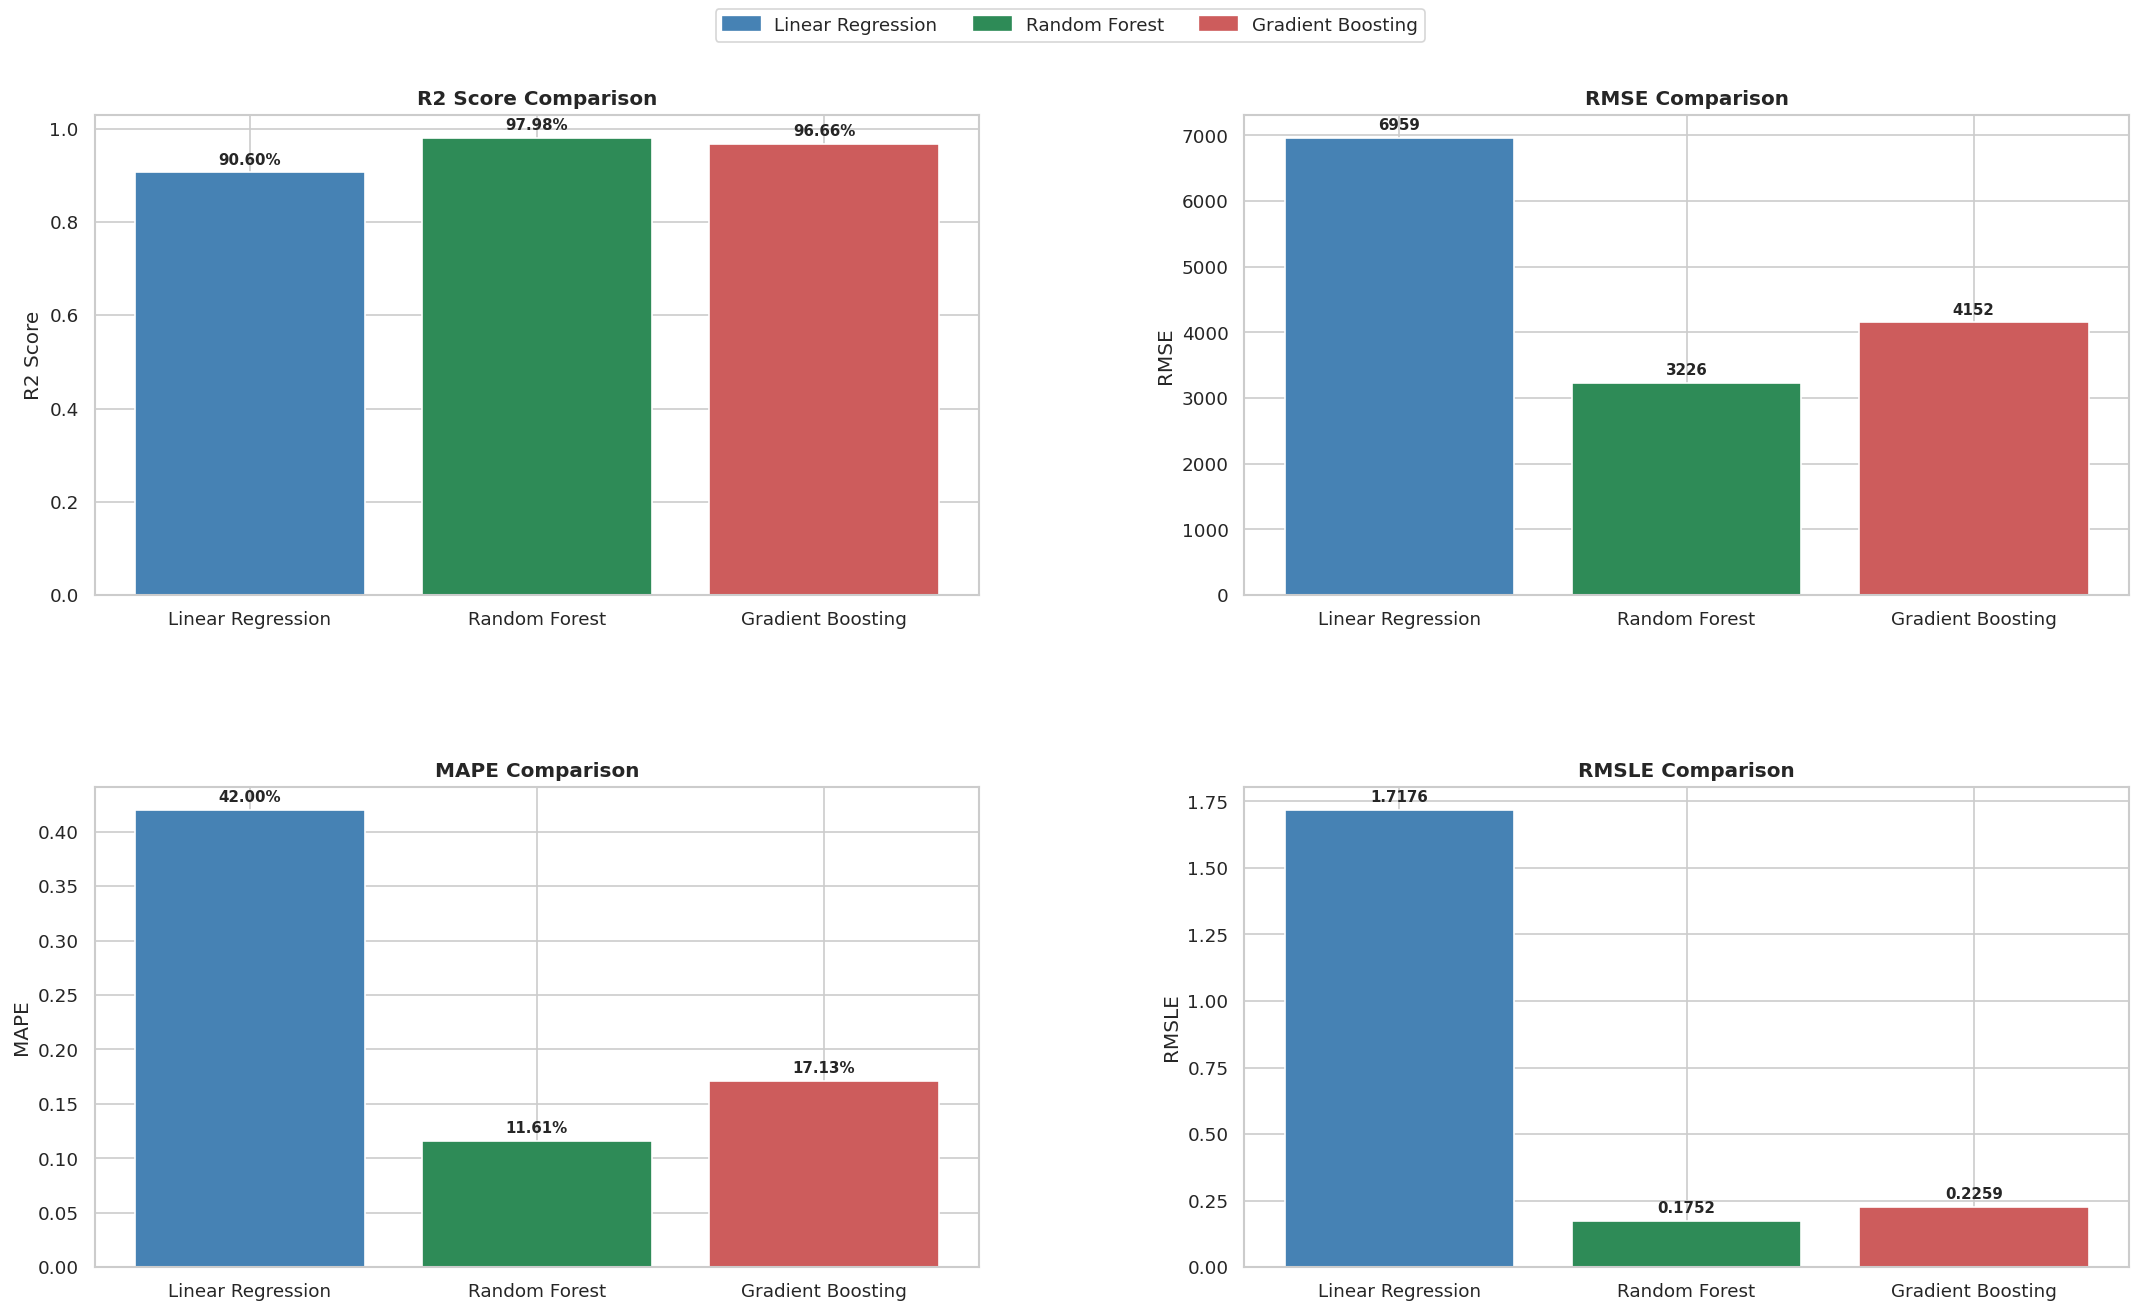

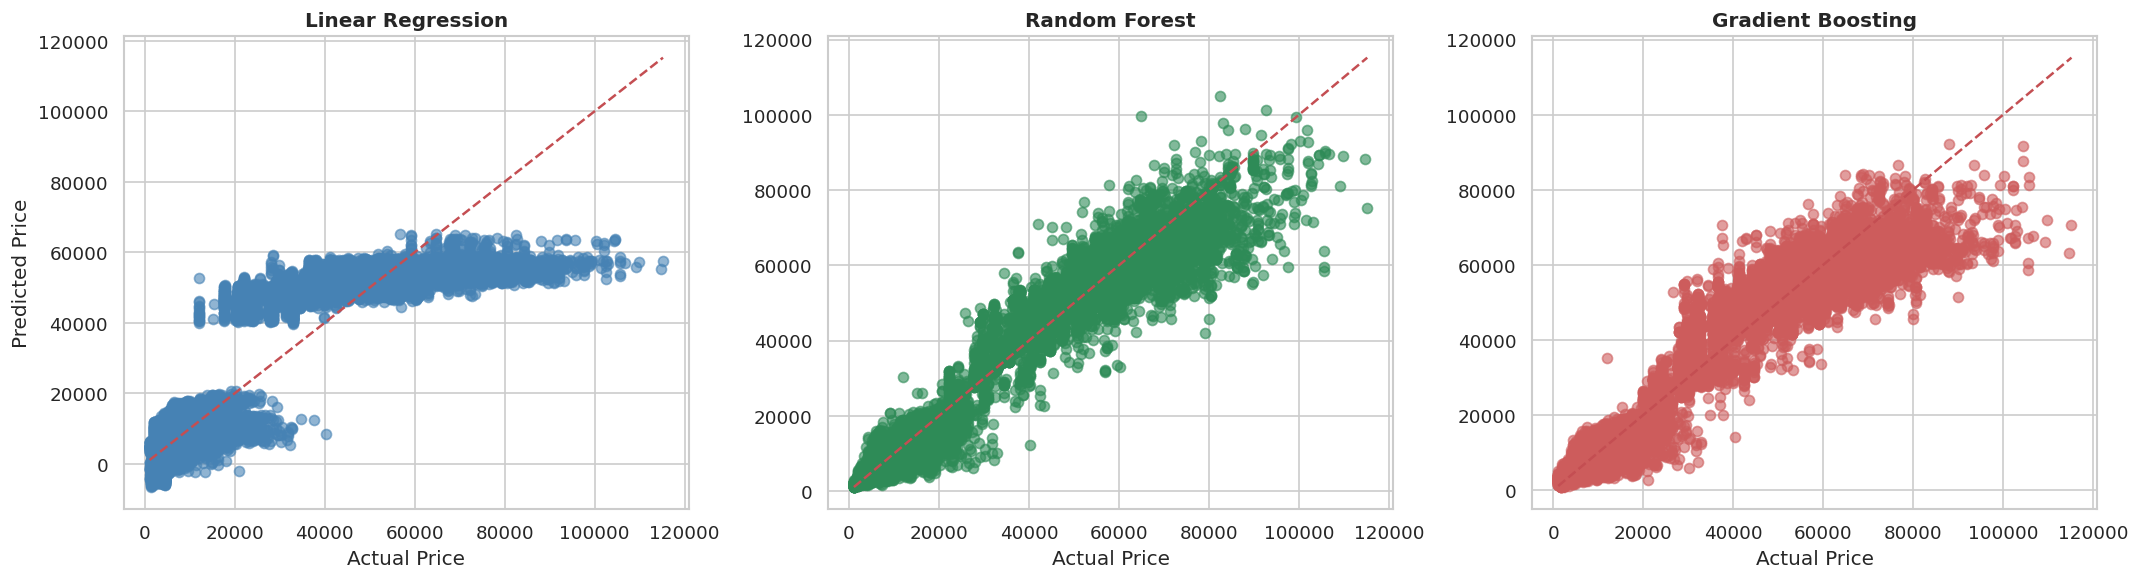

In [124]:
# Metrics Comparison between Models
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']

r2_scores = [lr_results[0], rf_results[0], gb_results[0]]
rmse_scores = [lr_results[1], rf_results[1], gb_results[1]]
mape_scores = [lr_results[2], rf_results[2], gb_results[2]]
rmsle_scores = [lr_results[3], rf_results[3], gb_results[3]]

colors = ['steelblue', 'seagreen', 'indianred']

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# R2
bars1 = axes[0, 0].bar(models, r2_scores, color=colors)
axes[0, 0].set_title("R2 Score Comparison", fontweight='bold')
axes[0, 0].set_ylabel("R2 Score")
axes[0, 0].bar_label(
    bars1,
    labels=[f'{x*100:.2f}%' for x in r2_scores],
    padding=3,
    fontsize=9,
    fontweight='bold')
# RMSE
bars2 = axes[0, 1].bar(models, rmse_scores, color=colors)
axes[0, 1].set_title("RMSE Comparison", fontweight='bold')
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].bar_label(
    bars2,
    fmt='%.0f',
    padding=3,
    fontsize=9,
    fontweight='bold')
# MAPE
bars3 = axes[1, 0].bar(models, mape_scores, color=colors)
axes[1, 0].set_title("MAPE Comparison", fontweight='bold')
axes[1, 0].set_ylabel("MAPE")
axes[1, 0].bar_label(
    bars3,
    labels=[f'{x*100:.2f}%' for x in mape_scores],
    padding=3,
    fontsize=9,
    fontweight='bold')
# RSMLE
bars4 = axes[1, 1].bar(models, rmsle_scores, color=colors)
axes[1, 1].set_title("RMSLE Comparison", fontweight='bold')
axes[1, 1].set_ylabel("RMSLE")
axes[1, 1].bar_label(
    bars4,
    fmt='%.4f',
    padding=3,
    fontsize=9,
    fontweight='bold')

legend_labels = [
    mpatches.Patch(color='steelblue', label='Linear Regression'),
    mpatches.Patch(color='seagreen', label='Random Forest'),
    mpatches.Patch(color='indianred', label='Gradient Boosting')]

fig.legend(handles=legend_labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.savefig('Metrics Comparison.png')
plt.show()

print('\n')
# Model----Actual Vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue')
axes[0].set_title("Linear Regression", fontweight='bold')
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='seagreen')
axes[1].set_title("Random Forest", fontweight='bold')
axes[1].set_xlabel("Actual Price")
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
# Gradient Boosting
axes[2].scatter(y_test, y_pred_gb, alpha=0.6, color='indianred')
axes[2].set_title("Gradient Boosting", fontweight='bold')
axes[2].set_xlabel("Actual Price")
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')

plt.tight_layout()
plt.savefig('Models - Actual Vs Predicted.png')
plt.show()

In [125]:
# Summary
print('='*25, 'SUMMARY', '='*25)
print(f"{'─'*25}")
print("LINEAR REGRESSION")
print(f"{'─'*25}")
print(f'R2: {lr_results[0]*100:.2f}%')
print(f'RMSE: {lr_results[1]:.4f}')
print(f'MAPE: {lr_results[2]*100:.2f}%')
print(f'RMSLE: {lr_results[3]:.4f}')
print(f"{'─'*25}")
print("RANDOM FOREST")
print(f"{'─'*25}")
print(f'R2: {rf_results[0]*100:.2f}%')
print(f'RMSE: {rf_results[1]:.4f}')
print(f'MAPE: {rf_results[2]*100:.2f}%')
print(f'RMSLE: {rf_results[3]:.4f}')
print(f"{'─'*25}")
print("GRADIENT BOOSTING")
print(f"{'─'*25}")
print(f'R2: {gb_results[0]*100:.2f}%')
print(f'RMSE: {gb_results[1]:.4f}')
print(f'MAPE: {gb_results[2]*100:.2f}%')
print(f'RMSLE: {gb_results[3]:.4f}')
print(f"{'─'*25}")

========================= SUMMARY =========================
─────────────────────────
LINEAR REGRESSION
─────────────────────────
R2: 90.60%
RMSE: 6959.3027
MAPE: 42.00%
RMSLE: 1.7176
─────────────────────────
RANDOM FOREST
─────────────────────────
R2: 97.98%
RMSE: 3226.2902
MAPE: 11.61%
RMSLE: 0.1752
─────────────────────────
GRADIENT BOOSTING
─────────────────────────
R2: 96.66%
RMSE: 4151.9800
MAPE: 17.13%
RMSLE: 0.2259
─────────────────────────


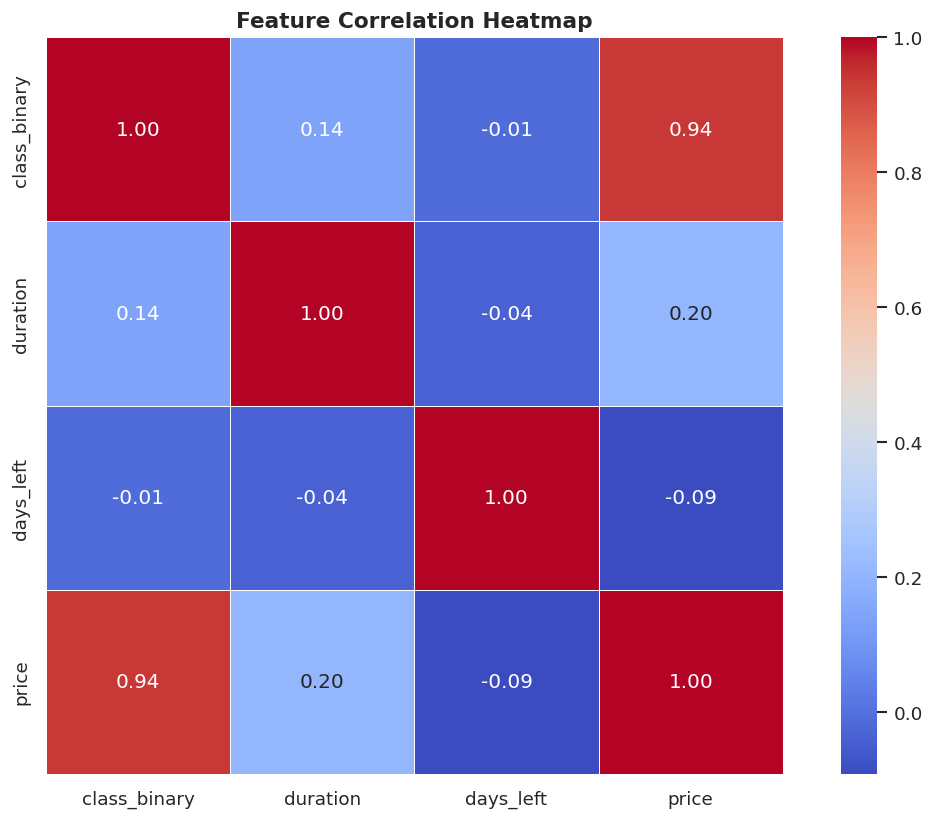

In [120]:
# Feature Correlation Heatmap
corr_df = df_model[['class_binary', 'duration', 'days_left','price']]
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13,
          fontweight='bold')
plt.tight_layout()
plt.savefig('Feature Correlation Heatmap.png')
plt.show()
